# **Task D**

- Name : Vaishnavi Agarwal
- Roll No. : 230150028

# Importing Libraries

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Defining Functions

In [39]:
def naive_DFT(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        s = 0.0
        for n in range(N):
            s += x[n] * np.exp(-2j * np.pi * k * n / N)
        X[k] = s
    return X

# **(a) Execution Time for Powers of Two**

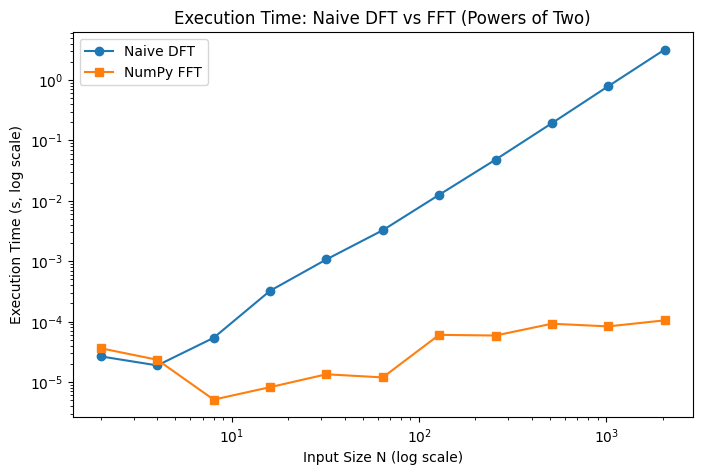

In [40]:
N_values = [2**k for k in range(1, 12)]  
time_dft = []
time_fft = []
np.random.seed(10)
for N in N_values:
    x = np.random.randn(N)
    
    # Naive DFT 
    start = time.perf_counter()
    naive_DFT(x)
    end = time.perf_counter()
    time_dft.append(end - start)
    
    # NumPy FFT 
    start = time.perf_counter()
    np.fft.fft(x)
    end = time.perf_counter()
    time_fft.append(end - start)

# plot 
plt.figure(figsize=(8,5))
plt.plot(N_values, time_dft, marker='o', label="Naive DFT")
plt.plot(N_values, time_fft, marker='s', label="NumPy FFT")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size N (log scale)")
plt.ylabel("Execution Time (s, log scale)")
plt.title("Execution Time: Naive DFT vs FFT (Powers of Two)")
plt.legend()
plt.show()

In [41]:
print(time_dft)
print(time_fft)

[2.6499999876250513e-05, 1.880000036180718e-05, 5.3900000239082146e-05, 0.0003234999994674581, 0.0010717000004660804, 0.003260000000409491, 0.012586599999849568, 0.048088499999721535, 0.1931907999996838, 0.7908840000000055, 3.196795199999542]
[3.609999930631602e-05, 2.3300000066228677e-05, 5.100000635138713e-06, 8.199999683711212e-06, 1.340000017080456e-05, 1.1899999663000926e-05, 6.029999985912582e-05, 5.880000026081689e-05, 9.210000007442432e-05, 8.330000036949059e-05, 0.00010479999946255703]


Execution time of naive DFT grows quadratically with N.</br>
Execution time of FFT grows near-linearly (N log N).</br>

# **(b) Execution Time for Non-Powers of Two**

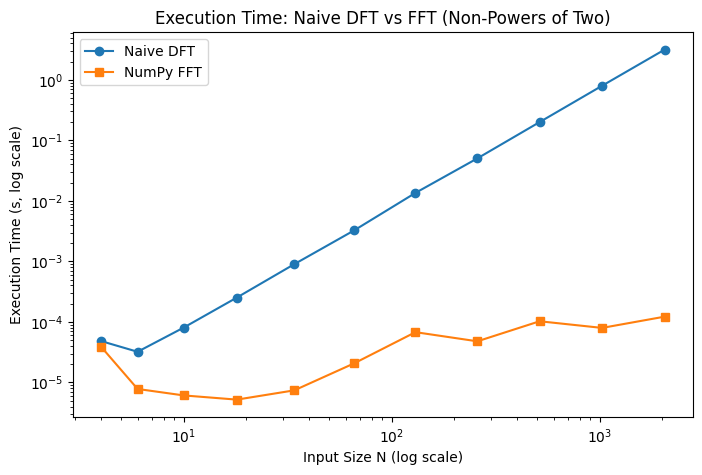

In [42]:

N_values_non = [2**k + 2 for k in range(1, 12)]  # N = 4,6,...2050
time_dft_non = []
time_fft_non = []
np.random.seed(10)
for N in N_values_non:
    x = np.random.randn(N)
    
    # Naive DFT
    start = time.perf_counter()
    naive_DFT(x)
    end = time.perf_counter()
    time_dft_non.append(end - start)
    
    # FFT
    start = time.perf_counter()
    np.fft.fft(x)
    end = time.perf_counter()
    time_fft_non.append(end - start)

# plot
plt.figure(figsize=(8,5))
plt.plot(N_values_non, time_dft_non, marker='o', label="Naive DFT")
plt.plot(N_values_non, time_fft_non, marker='s', label="NumPy FFT")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size N (log scale)")
plt.ylabel("Execution Time (s, log scale)")
plt.title("Execution Time: Naive DFT vs FFT (Non-Powers of Two)")
plt.legend()
plt.show()


In [43]:
print(time_dft_non)
print(time_fft_non)

[4.830000034417026e-05, 3.20999997711624e-05, 8.060000072873663e-05, 0.00025240000013582176, 0.000899599999684142, 0.003256599999986065, 0.013533999999708612, 0.05033669999920676, 0.20031010000002425, 0.7974748999995427, 3.1539931999996043]
[3.910000032192329e-05, 7.800000275892671e-06, 6.100000064179767e-06, 5.200000487093348e-06, 7.3999999585794285e-06, 2.0700000277429353e-05, 6.769999981770525e-05, 4.779999926540768e-05, 0.00010249999922962161, 7.960000039020088e-05, 0.00012210000022605527]


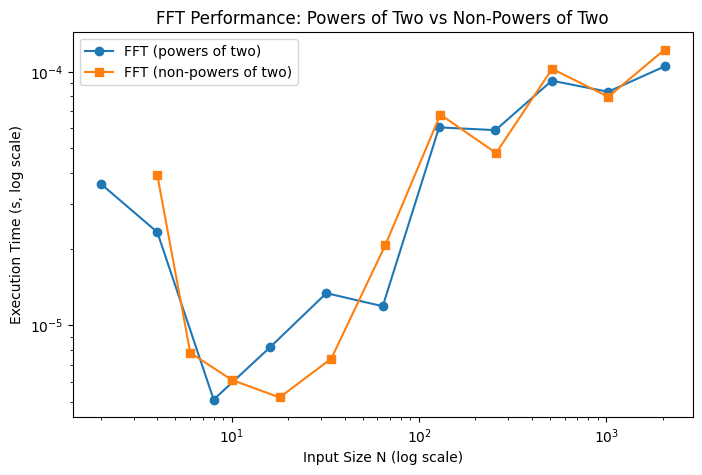

In [44]:
plt.figure(figsize=(8,5))
plt.plot(N_values, time_fft, marker='o', label="FFT (powers of two)")
plt.plot(N_values_non, time_fft_non, marker='s', label="FFT (non-powers of two)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size N (log scale)")
plt.ylabel("Execution Time (s, log scale)")
plt.title("FFT Performance: Powers of Two vs Non-Powers of Two")
plt.legend()
plt.show()


- For small N (below 20), both are noisy i.e. timing is inconsistent because execution is extremely fast</br>
- For medium-to-large N (32 to 2048):</br>

  - The powers-of-two curve (blue) generally dips lower than the non-powers curve (orange).
  - This means FFT is slightly faster when N is exactly a power of two.

# **(c) Insight and Analysis**



**Why FFT is efficient for powers of two?**

FFT recursively splits DFT into smaller parts (divide-and-conquer).

When 𝑁=2^𝑘, this splitting is perfectly balanced i.e. maximum efficiency.

**Why slower for non-powers-of-two?**

FFT implementations fall back to mixed-radix or prime factor algorithms.
These are less efficient than radix-2 FFT, so runtime increases.



**Real-world implications:**

FFT dominates DFT in performance for large N (orders of magnitude faster). Naive DFT is only acceptable for very small N (e.g., N < 32).
In practice, signals are often zero-padded to nearest power-of-two length to leverage FFT.

# Extend the plot to show the ratio of execution times (DFT / FFT) versus N to visualize the speed-up factor.

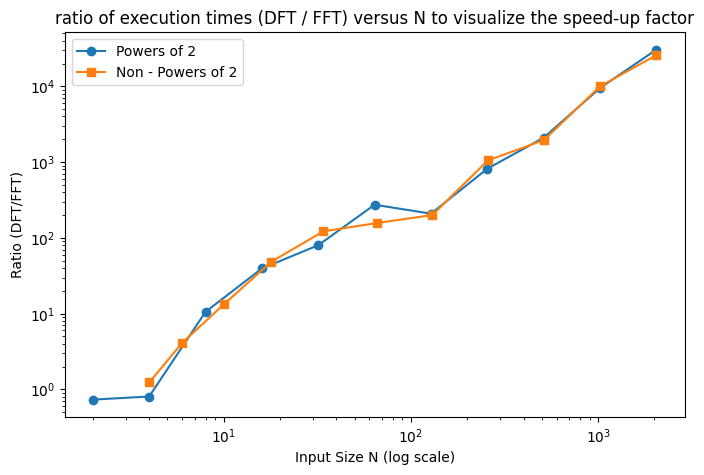

In [47]:
plt.figure(figsize=(8,5))
dft_fft = []
dft_fft_non=[]

for i in range(len(N_values)):
    dft_fft.append(time_dft[i]/time_fft[i])
    dft_fft_non.append(time_dft_non[i]/time_fft_non[i])


plt.plot(N_values, dft_fft, marker='o', label="Powers of 2")
plt.plot(N_values_non, dft_fft_non, marker='s', label="Non - Powers of 2")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size N (log scale)")
plt.ylabel("Ratio (DFT/FFT)")
plt.title("ratio of execution times (DFT / FFT) versus N to visualize the speed-up factor")
plt.legend()
plt.show()